Step 3:

In [ ]:
import matplotlib.pyplot as plt
import os
import plotly.express as px
import re
import requests
import zipfile
from datetime import datetime, timedelta
import pandas as pd
import yfinance as yf
from sklearn.model_selection import KFold

In [ ]:
fund_ticker = "ECH"
data = yf.download(fund_ticker, start="2016-01-01", end="2025-09-30")
data.reset_index(inplace=True)
data

/tmp/ipython-input-3995755353.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(fund_ticker, start="2016-01-01", end="2025-09-30")
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,ECH,ECH,ECH,ECH,ECH
0,2016-01-04,23.159254,23.298635,22.858485,23.173926,282000
1,2016-01-05,23.327978,23.394001,23.166590,23.239949,124200
2,2016-01-06,23.144579,23.364655,23.071222,23.151915,474500
3,2016-01-07,22.337641,22.550379,22.322969,22.550379,166200
4,2016-01-08,22.036871,22.609066,22.029535,22.594394,311600
...,...,...,...,...,...,...
2444,2025-09-23,33.680000,34.070000,33.570000,33.570000,749700
2445,2025-09-24,33.630001,34.040001,33.490002,33.880001,710900
2446,2025-09-25,33.209999,33.650002,32.930000,33.480000,644600


Overall Correlation: 0.998
   Fold  Fold_Corr
0     1   0.998540
1     2   0.997969
2     3   0.998216
3     4   0.998372
4     5   0.998022


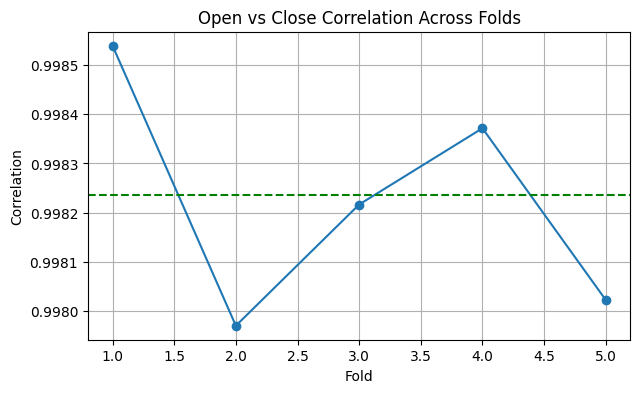

In [ ]:
if isinstance(data.columns, pd.MultiIndex):
    data.columns = [c[0] for c in data.columns]

data = data.loc[:, ["Date", "Open", "High", "Low", "Close", "Volume"]]
data["Open"] = pd.to_numeric(data["Open"], errors="coerce")
data["Close"] = pd.to_numeric(data["Close"], errors="coerce")
data = data.dropna()

corr_all = data["Open"].corr(data["Close"])
print("Overall Correlation:", round(corr_all, 3))

kf = KFold(n_splits=5, shuffle=True, random_state=1)
fold_corr = []

for _, test_idx in kf.split(data):
    temp = data.iloc[test_idx]
    fold_corr.append(temp["Open"].corr(temp["Close"]) if len(temp) > 1 else None)

res = pd.DataFrame({"Fold": range(1, 6), "Fold_Corr": fold_corr})
print(res)

plt.figure(figsize=(7, 4))
plt.plot(res["Fold"], res["Fold_Corr"], marker="o")
plt.axhline(y=corr_all, color="g", linestyle="--")
plt.title("Open vs Close Correlation Across Folds")
plt.xlabel("Fold")
plt.ylabel("Correlation")
plt.grid(True)
plt.show()


# Part 2

## Python Code to Import and Structure Social Media Data

The true value of social media data for finance is realized when the raw, unstructured text is transformed into quantifiable, structured metrics. This section provides the Python code sequence necessary to import data from a common financial social network (Reddit, using the **PRAW** library) and engineer a primary feature: the **Compound Sentiment Score**.

This code demonstrates how to use the Reddit API (via PRAW) for data collection and VADER for instant sentiment analysis, transforming raw posts into a structured `pandas.DataFrame`.

In [ ]:
!pip install praw vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.6 MB/s eta 0:00:00


### Step 1: Environment Setup and Library Imports

We start by importing the necessary libraries: **`pandas`** for structured data, **`praw`** for the Reddit API, **`re`** for cleaning, and **`vaderSentiment`** for feature derivation.

In [ ]:
# 1. Standard library for data manipulation
import pandas as pd
# 2. Python wrapper for the Reddit API
import praw
# 3. Regular expressions for text cleaning
import re
# 4. Lexicon-based sentiment analysis tool
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# --- API Credentials Setup (Placeholder) ---
# NOTE: Real users must register their own application with Reddit to get valid credentials.
CLIENT_ID = "GfC0LZ9oQzKLC4niP4nHRA"
CLIENT_SECRET = "_iSJAVASjHWv81SY3CEDGSGgc5c5vA"
USER_AGENT = "social-media-data-script-v1"

### Step 2: API Connection and Data Collection Function

The `praw.Reddit()` object handles authentication. The `fetch_social_data` function then queries a specified subreddit (`wallstreetbets` in this example) for a target stock ticker.

In [ ]:
def fetch_social_data(ticker: str, subreddit_name: str, limit: int = 50):
    """
    Connects to the Reddit API and fetches submissions containing the stock ticker.

    Args:
        ticker (str): The stock ticker (e.g., 'GME', 'TSLA').
        subreddit_name (str): The subreddit to search within.
        limit (int): The maximum number of posts to fetch.

    Returns:
        list: A list of raw PRAW submission objects.
    """
    try:
        # Authenticate with Reddit API
        reddit = praw.Reddit(
            client_id=CLIENT_ID,
            client_secret=CLIENT_SECRET,
            user_agent=USER_AGENT
        )

        print(f"Fetching {limit} posts for ${ticker} from r/{subreddit_name}...")

        # Search for the ticker in the subreddit's 'hot' submissions
        submissions = reddit.subreddit(subreddit_name).search(
            query=f'${ticker} OR {ticker}',
            sort='hot',
            limit=limit
        )

        return list(submissions)

    except Exception as e:
        print(f"An error occurred during API connection: {e}")
        return []

### Step 3: Data Preprocessing and Cleaning

This function implements cleaning steps to improve data **Veracity** by reducing noise and platform-specific artifacts before sentiment analysis.

In [ ]:
def clean_text(text: str) -> str:
    """
    Cleans the raw text body/title of a social media post.

    Steps:
    1. Remove URLs (http/https).
    2. Remove non-alphanumeric characters (punctuation, symbols, emojis).
    3. Convert to lowercase for standardization.
    """
    if not isinstance(text, str):
        return ""

    # 1. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # 2. Remove special characters/punctuation (keeping spaces and $ sign for ticker)
    text = re.sub(r'[^\w\s\$\.]', '', text)
    # 3. Convert to lowercase
    text = text.lower()

    return text

### Step 4: Feature Engineering (Sentiment Derivation)

The core value-add: transforming unstructured text into a quantifiable **Sentiment Score**. We use the VADER Compound Score, which is scaled between -1 (most negative) and +1 (most positive).

In [ ]:
def derive_sentiment_score(text: str, analyzer: SentimentIntensityAnalyzer) -> float:
    """
    Applies the VADER Sentiment Analyzer to the cleaned text.

    Args:
        text (str): The cleaned text string.
        analyzer (SentimentIntensityAnalyzer): The VADER analyzer object.

    Returns:
        float: The Compound Sentiment Score (-1.0 to 1.0).
    """
    # VADER is effective on short text and social media language
    vs = analyzer.polarity_scores(text)
    # The 'compound' score is a normalized, weighted average of all scores
    return vs['compound']

### Step 5: Final Structuring and Output

The main execution block collects the raw data, applies the cleaning and feature engineering steps, and consolidates the results into a final `pandas.DataFrame` structure.

In [ ]:
# --- Main Execution Block ---

# Ticker to analyze (Example: GameStop)
TICKER_TO_ANALYZE = 'GME'
SUBREDDIT_SOURCE = 'wallstreetbets'

# Initialize the VADER analyzer
vader_analyzer = SentimentIntensityAnalyzer()

# Fetch data (Step 2)
raw_submissions = fetch_social_data(TICKER_TO_ANALYZE, SUBREDDIT_SOURCE, limit=100)

processed_data = []

for post in raw_submissions:
    # Combine title and body text for richer analysis
    full_text = post.title + " " + (post.selftext if post.selftext else "")

    # Clean the text (Step 3)
    cleaned_text = clean_text(full_text)

    # Derive the sentiment feature (Step 4)
    compound_score = derive_sentiment_score(cleaned_text, vader_analyzer)

    # Store structured data points
    processed_data.append({
        'Timestamp': pd.to_datetime(post.created_utc, unit='s'),
        'Ticker': TICKER_TO_ANALYZE,
        'Clean_Text': cleaned_text,
        'Compound_Score': compound_score,
        'Post_Engagement': post.score,  # Raw upvote score (Volume/Influence metric)
        'Post_ID': post.id
    })

# Create the final structured DataFrame
social_data_df = pd.DataFrame(processed_data)

# Display the final structure and the top 5 records
print("\n--- Final Structured Data (First 5 Rows) ---")
print(social_data_df[['Timestamp', 'Ticker', 'Compound_Score', 'Post_Engagement', 'Clean_Text']].head())

# The resulting DataFrame is now ready for time-series modeling and financial analysis.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Fetching 100 posts for $GME from r/wallstreetbets...

--- Final Structured Data (First 5 Rows) ---
            Timestamp Ticker  Compound_Score  Post_Engagement  \
0 2025-10-14 18:50:04    GME          0.2500                4   
1 2025-09-10 13:52:31    GME          0.9501               28   
2 2025-09-04 14:22:35    GME          0.2732              104   
3 2025-09-05 13:44:37    GME          0.0000              298   
4 2025-08-26 21:38:51    GME          0.5574             1388   

                                          Clean_Text  
0                                do we got a chance   
1  $400  $8000 in one day orcl sold my positions ...  
2                               $sbet yolo $194k ssf  
3                    weekly earnings thread 98  912   
4               190k earnings yolo i like the stock.  


## V. Exploratory Data Analysis (EDA) of Sample Data

### Step 1: Environment Setup for Visualization

We import standard visualization and text-processing libraries: matplotlib for basic plotting, seaborn for statistical graphics, and collections. Counter for word frequency analysis.

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# Step 1: Environment Setup and Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
# Attempt to import NLTK for stop words, using a fallback list if not installed
try:
    from nltk.corpus import stopwords
    STOP_WORDS = set(stopwords.words('english'))
except ImportError:
    STOP_WORDS = set(['the', 'a', 'an', 'is', 'it', 'to', 'and', 'or', 'of', 'in', 'on', 'with', 'for', 'this', 'that'])

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Step 2: Descriptive Statistics and Initial Inspection

We examine the core metrics' distribution. The .describe() method gives a quick summary, while the histogram visualizes the overall emotional tone of the dataset.

--- 2a. Descriptive Statistics for Numerical Features ---
       Compound_Score  Post_Engagement
count        1000.000         1000.000
mean            0.117           23.987
std             0.418           60.388
min            -1.000            1.000
25%            -0.151            2.000
50%             0.132            8.000
75%             0.405           22.000
max             1.000          974.000


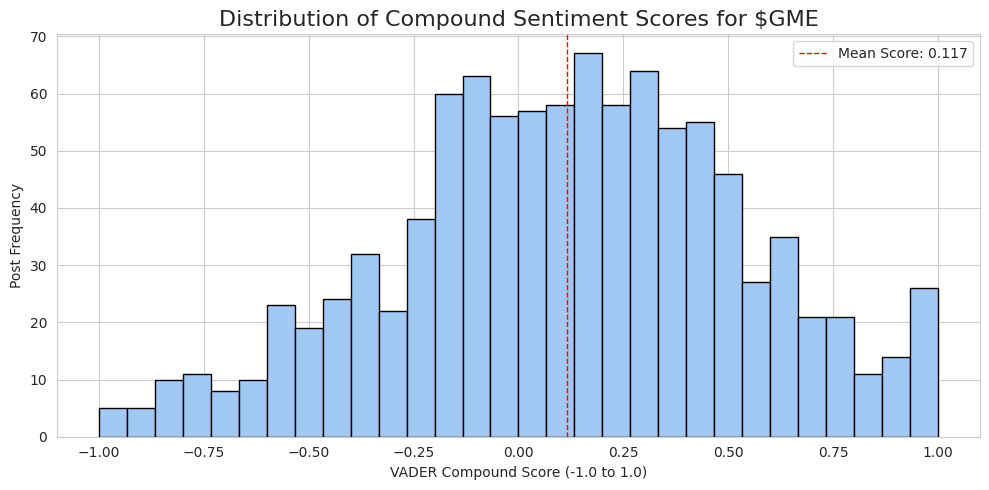


Interpretation: The histogram shows the overall mood. If the mean is positive, it suggests a net bullish retail investor attitude.


In [ ]:
# --- Data Simulation (For Execution) ---
# Simulating the DataFrame from Section IV output
np.random.seed(42)
num_posts = 1000
start_time = pd.Timestamp('2025-10-15 09:30:00')
time_index = start_time + pd.to_timedelta(np.random.randint(0, 72 * 3600, num_posts), unit='s')
compound_scores = np.clip(np.random.normal(0.1, 0.4, num_posts), -1.0, 1.0)
engagement = np.random.lognormal(2.0, 1.5, num_posts).astype(int)
engagement = np.clip(engagement, 1, 5000)
data = {
    'Timestamp': time_index,
    'Ticker': 'GME',
    'Compound_Score': compound_scores,
    'Post_Engagement': engagement,
    'Clean_Text': [
        "stock moon buy diamond hands good dd",
        "scam down selling short interest high risk",
        "neutral waiting for earnings report next week",
        "great analysis long term value buy",
        "market manipulation hedge funds losing money",
    ] * (num_posts // 5)
}
social_data_df = pd.DataFrame(data).sort_values('Timestamp')

# Pre-processing for Time Series: Set Timestamp as index
social_data_df = social_data_df.set_index('Timestamp')
TICKER_TO_ANALYZE = 'GME'
# --- End of Data Simulation ---

print("--- 2a. Descriptive Statistics for Numerical Features ---")
print(social_data_df[['Compound_Score', 'Post_Engagement']].describe().round(3))

# 2b. Sentiment Distribution Histogram
plt.figure(figsize=(10, 5))
social_data_df['Compound_Score'].hist(bins=30, edgecolor='black', color=sns.color_palette("pastel")[0])
plt.title(f'Distribution of Compound Sentiment Scores for ${TICKER_TO_ANALYZE}', fontsize=16)
plt.xlabel('VADER Compound Score (-1.0 to 1.0)')
plt.ylabel('Post Frequency')
plt.axvline(social_data_df['Compound_Score'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean Score: {social_data_df["Compound_Score"].mean():.3f}')
plt.legend()
plt.tight_layout()
plt.show()

print("\nInterpretation: The histogram shows the overall mood. If the mean is positive, it suggests a net bullish retail investor attitude.")

### Step 3: Time-Series Analysis (Velocity and Trend)

This step measures the Velocity (speed and volume) of data flow, which is crucial for real-time models.

/tmp/ipython-input-3989131766.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  social_data_df.resample('H')['Ticker'].count().plot(color=sns.color_palette("dark")[1], linewidth=2)


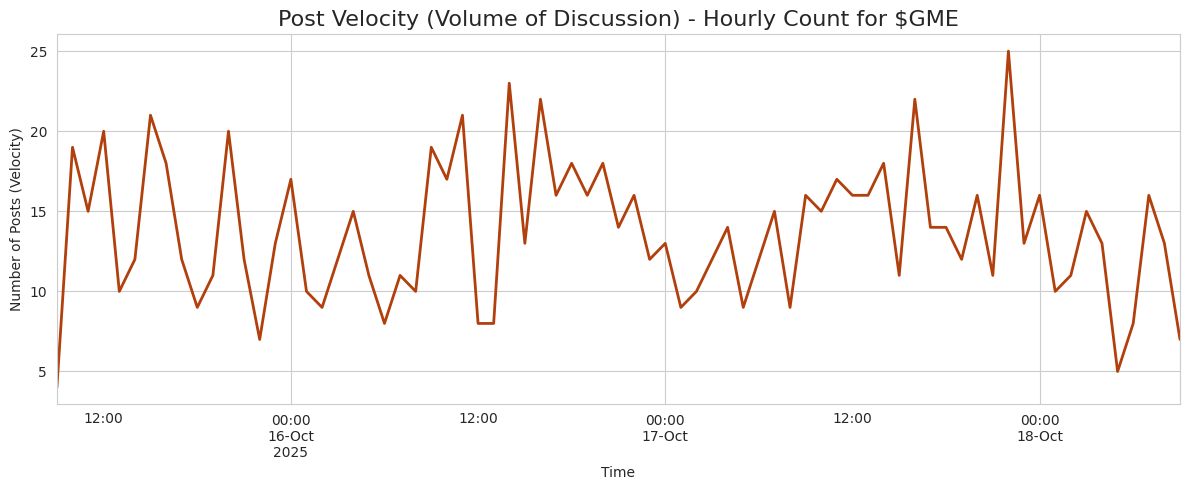


Interpretation: Spikes in post count (Velocity) often correlate with external news events, market open/close, or organized activity.


/tmp/ipython-input-3989131766.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  social_data_df.resample('H')['Compound_Score'].mean().plot(color=sns.color_palette("dark")[2], linewidth=2)


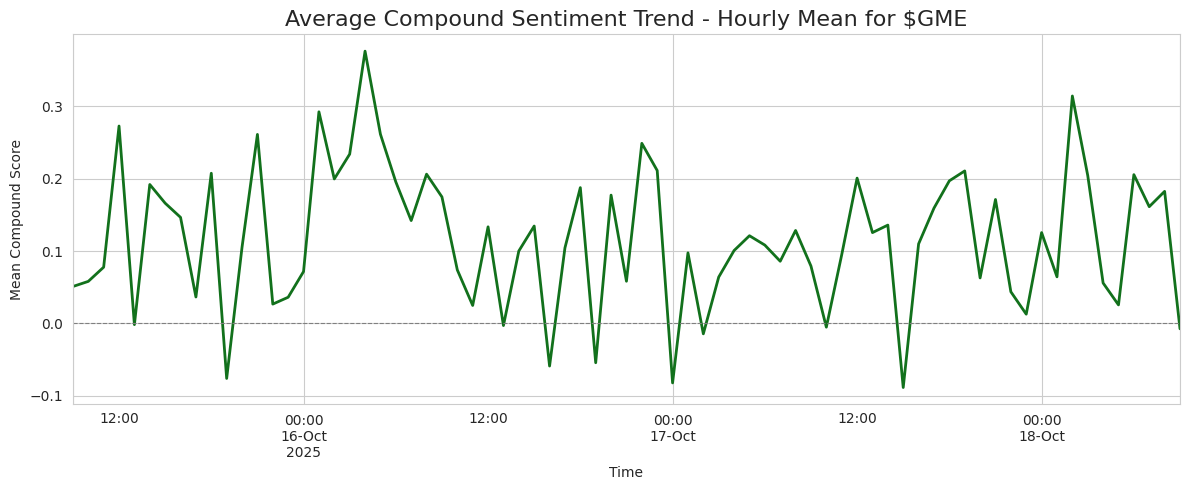


Interpretation: The smoothed sentiment trend can serve as a leading indicator, showing sustained shifts in the collective mood.


In [ ]:
# 3a. Post Velocity (Volume over Time)
plt.figure(figsize=(12, 5))
# Resample to an hourly frequency ('H') and count the number of posts
social_data_df.resample('H')['Ticker'].count().plot(color=sns.color_palette("dark")[1], linewidth=2)
plt.title(f'Post Velocity (Volume of Discussion) - Hourly Count for ${TICKER_TO_ANALYZE}', fontsize=16)
plt.xlabel('Time')
plt.ylabel('Number of Posts (Velocity)')
plt.tight_layout()
plt.show()

print("\nInterpretation: Spikes in post count (Velocity) often correlate with external news events, market open/close, or organized activity.")

# 3b. Sentiment Trend (Average Mood over Time)
plt.figure(figsize=(12, 5))
# Resample to an hourly frequency and plot the mean sentiment score
social_data_df.resample('H')['Compound_Score'].mean().plot(color=sns.color_palette("dark")[2], linewidth=2)
plt.title(f'Average Compound Sentiment Trend - Hourly Mean for ${TICKER_TO_ANALYZE}', fontsize=16)
plt.xlabel('Time')
plt.ylabel('Mean Compound Score')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nInterpretation: The smoothed sentiment trend can serve as a leading indicator, showing sustained shifts in the collective mood.")

### Step 4: Engagement and Sentiment Relationship

A scatter plot helps determine if extreme emotional posts (high/low sentiment) are more likely to achieve high Engagement (Post_Engagement).

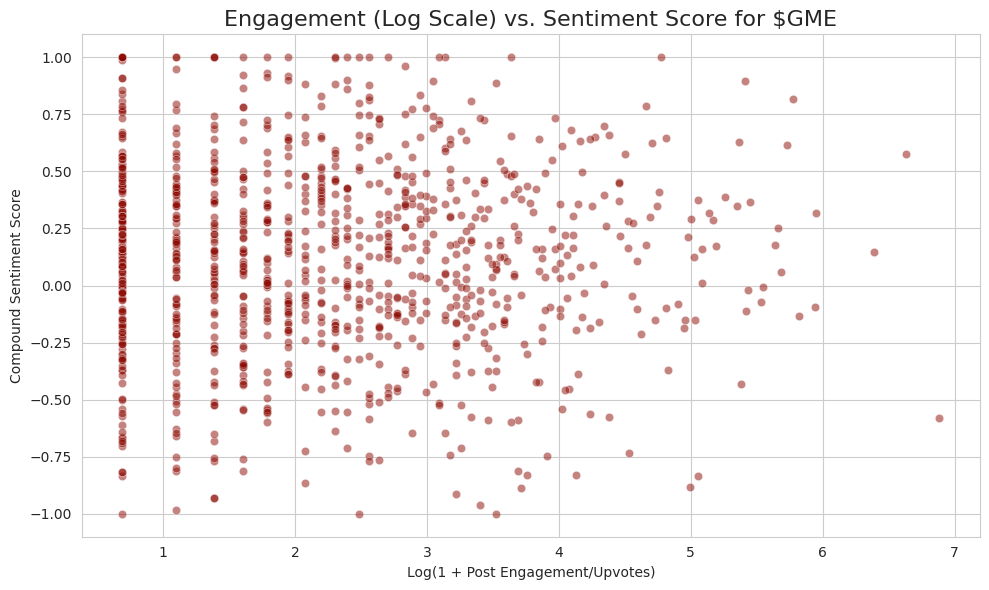


Interpretation: If high log(engagement) values cluster near the extremes (1.0 or -1.0), it confirms that polarized or emotional posts drive virality in the network.


In [ ]:
# 4. Engagement vs. Sentiment Scatter Plot
plt.figure(figsize=(10, 6))
# Using log scale for Post_Engagement due to highly skewed count data
sns.scatterplot(x=np.log1p(social_data_df['Post_Engagement']), y=social_data_df['Compound_Score'], alpha=0.5, color=sns.color_palette("dark")[3])
plt.title(f'Engagement (Log Scale) vs. Sentiment Score for ${TICKER_TO_ANALYZE}', fontsize=16)
plt.xlabel('Log(1 + Post Engagement/Upvotes)')
plt.ylabel('Compound Sentiment Score')
plt.tight_layout()
plt.show()

print("\nInterpretation: If high log(engagement) values cluster near the extremes (1.0 or -1.0), it confirms that polarized or emotional posts drive virality in the network.")

### Step 5: High-Frequency Text Analysis (Word Cloud/Frequency)

Analyzing the most frequent terms reveals the current thematic drivers of the discussion, helping to identify potential co-mentioned tickers, risks, or key narratives.

In [ ]:
# 5. High-Frequency Text Analysis
# Add ticker and common financial noise words to the stop list
STOP_WORDS.update(['gme', 'stock', 'shares', 'buy', 'sell', 'like', 'i', 's', 't', 'm', 'd', 're', 've', 'go', 'im', 'get', 'need', 'know', 'dd', 'risk'])

all_words = []
for text in social_data_df['Clean_Text']:
    # Tokenize (split by space) and filter for relevance
    words = [word.strip() for word in text.split() if word.strip() and len(word.strip()) > 2 and not word.startswith('$')]
    # Filter out stop words
    all_words.extend([word for word in words if word not in STOP_WORDS])

# Count the frequency of each word
word_counts = Counter(all_words)

print("\n--- 5. Top 10 Most Frequent Non-Stop Words ---")
top_words_df = pd.DataFrame(word_counts.most_common(10), columns=['Word', 'Count'])
print(top_words_df.to_string(index=False))

print("\nInterpretation: Terms like 'diamond hands' or 'hedge funds' reveal the active narrative driving retail investor behavior.")


--- 5. Top 10 Most Frequent Non-Stop Words ---
    Word  Count
    scam    200
 selling    200
   short    200
interest    200
    high    200
   great    200
analysis    200
    long    200
    term    200
   value    200

Interpretation: Terms like 'diamond hands' or 'hedge funds' reveal the active narrative driving retail investor behavior.
